In [ ]:
%reload_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pylab as plt

from scipy.stats import multivariate_normal as norm
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['image.cmap'] = 'Grays'

# Fix the random seed to facilitate grading
np.random.seed(1)

# HW3.1 - Bayesian linear regression

In this notebook, we aim to understand Bayesian learning through a simple example. You will build the ingredients of Bayesian linear regression, define a prior over the model parameters, generate noisy observations, and update your belief about the parameters after seeing data. This will let you study how Bayesian linear regression supports parameter estimation, function prediction, and uncertainty quantification. In the next homework, we will then connect these ideas to the logic behind Bayesian optimization.

## 1.a Problem setup

In this section, we focus on Bayesian linear regression. The goal is to recover the model weights and learn an unknown function from noisy observations, while keeping track of both the current estimate and its uncertainty. The development follows closely the example in Figure 3.7 of [1].

We first generate a synthetic dataset. We assume that each target value $t$ is produced by a deterministic linear function $\hat{y}(x, w) = w_0 + w_1 x$ plus additive Gaussian noise:
$$
t = \hat{y}(x, w) + \epsilon,
$$

Where, $\epsilon \sim \mathcal{N}(0, \beta)$ is a zero-mean Gaussian random variable with variance $\beta$. Therefore, the conditional distribution of the observation is
$$
p(t \mid x, w, \beta) = \mathcal{N}\!\left(t \mid \hat{y}(x, w), \beta\right).
$$

We define the true parameter vector $w_{\mathrm{true}}$ of the ground-truth function $\hat{y}(x, w_{\mathrm{true}})$. The goal is to use Bayesian linear regression, using active learning, to estimate the value of $w_{\mathrm{true}}$ from noisy observations.

In [ ]:
## simple example 
beta = 0.05**2   # Noise std
w_true = np.array([-0.3, 0.5]) # Ground truth parameters

def y(x, w):
    # Basis [1, x]
    return w[0] + w[1] * x

In [ ]:
def generate_data(w, beta, x=None):
    noise = np.random.normal(0, np.sqrt(beta))
    if x is None:
        x = np.random.rand()
    t = y(x, w) + noise
    return np.array([x]), float(t)

x_grid = np.linspace(0, 1, 100)
t_true = y(x_grid, w_true)

data = list(zip(*[generate_data(w_true, beta) for _ in range(30)]))

plt.figure(figsize=(6, 4))
plt.plot(x_grid, t_true, color='C0')
plt.scatter(*data, color='C1')
plt.show()

### Define prior and function class

We now define the model used for Bayesian linear regression. We choose as our prediction function the following class of functions:
$$
y(x, w) = \Phi(x)^T w,
$$
where $\Phi$ is simply the linear basis
$$
\Phi(x) = [1, x].
$$
Note that we "cheated" a bit by choosing the perfect function class (the ground-truth data-generating function is exactly in that class). In a real-world setting, you would typically need to guess a good model from some data samples or prior knowledge. 
We place a Gaussian prior on the weights,
$$
w \sim \mathcal{N}(m_0, S_0),
$$
with prior mean $m_0 = 0$ and prior covariance $S_0 = \alpha I$. 

(6 pts) **1.a.1** We start by setting up two of the three kinds of plots shown in Figure 3.7 [1] and plotting its first row. For that, in the below code, do the following: 
- Implement the linear basis function $\Phi(x)$ and the prediction function $y_{\mathrm{est}}(x, w)$.
- Implement the prior distribution over $w$ and plot it (middle plot).
- Sample 10 different $w$ from the prior distribution and plot those functions (right plot).
When you're done, your plot should look similar to the following:
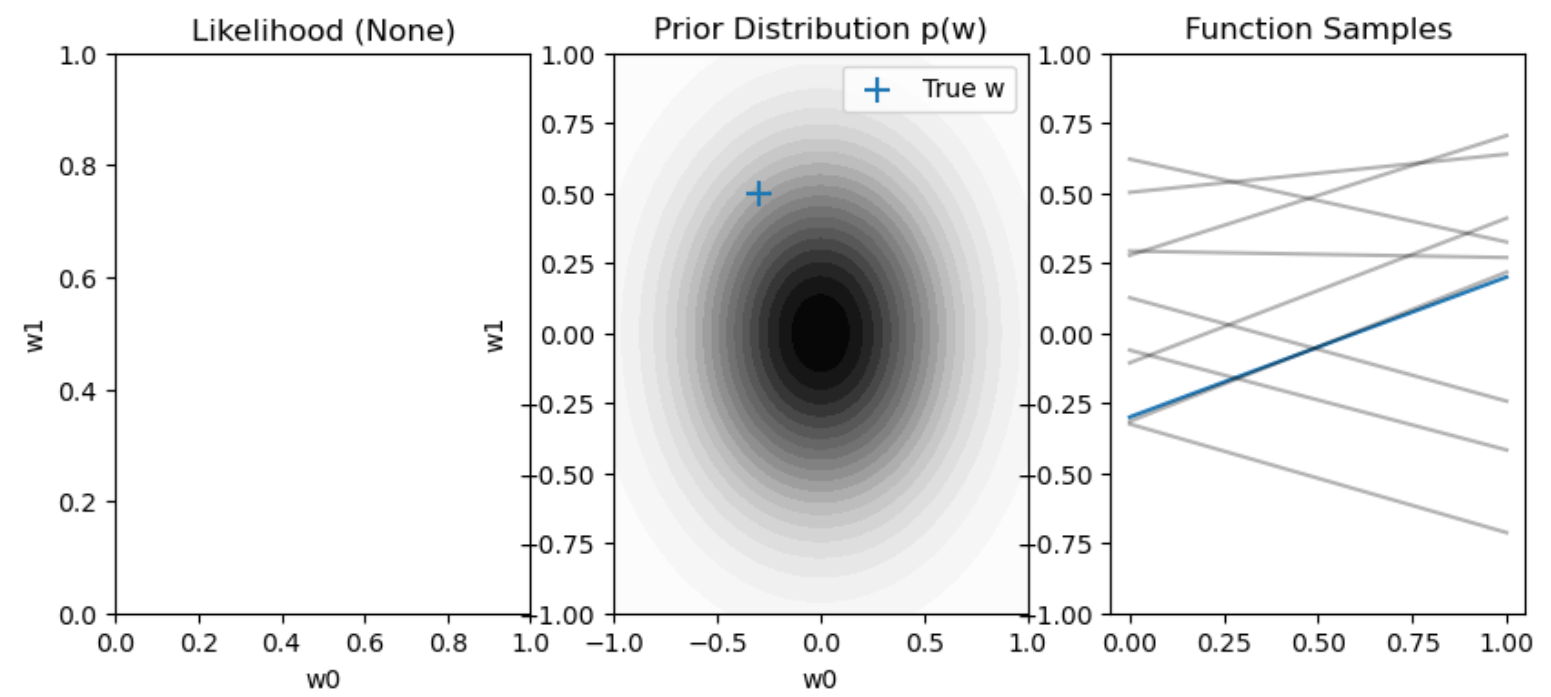

*Hint: use the function **norm** imported in the first cell.*

In [ ]:
### ============= 1.a.1 Fill in below ==============

def phi(x, K):
    ### Implement the basis function
    return None

def y_est(x, w):
    ### Implement the prediction function
    return None

### ===========================

In [ ]:
# Define prior
K = 2 
alpha = 0.2

m_0 = np.zeros(K) # mean
S_0 = alpha * np.eye(K) # covariance

# Create a grid of w values for visualization (heatmap)
w_vals = [np.linspace(-1, 1, 100)] * K
W_list = np.meshgrid(*w_vals)
w_array = np.stack(W_list, axis=-1)
W0, W1 = W_list

fig, axes = plt.subplots(1, 3)

# Left plot: Likelihood (Empty for now)
axes[0].set_title('Likelihood (None)')
axes[0].set_xlabel('w0')
axes[0].set_ylabel('w1')

# Middle plot: Current distribution of w (Prior), first two dimensions

### ============= 1.a.1 Fill in below ==============
### Implement the prior distribution over w as a heatmap or contourf plot. 
prior_pdf = None
axes[1].contourf(W0, W1, prior_pdf, levels=20)

### ===========================
axes[1].scatter(w_true[0], w_true[1], c='C0', marker='+', s=100, label='True w')
axes[1].set_title('Prior Distribution p(w)')
axes[1].set_xlabel('w0')
axes[1].set_ylabel('w1')
axes[1].legend()

# Right plot: Samples from resulting functions
axes[2].plot(x_grid, t_true, 'C0', label='Ground Truth')

### Sample 10 different $w$ from the prior distribution and plot those functions.

### ============= 1.a.1 Fill in below ==============
### Plot 10 samples of the function class. 

# solution 
for i in range(10):
    t_grid = None
    axes[2].plot(x_grid, t_grid, 'k-', alpha=0.3)
### ===========================

axes[2].set_title('Function Samples')
axes[2].set_ylim(-1, 1)
plt.show()

### Compute likelihood and posterior

We now use a new datapoint $(x, t)$ to update our belief about the weight vector $w$. Under the Gaussian noise model, the likelihood measures how well each candidate weight vector explains the observed data. By combining the likelihood with the prior distribution, we obtain the posterior distribution over $w$. 

(10 pts) **1.a.2** Implement the second row of the Figure:
- Implement the likelihood $p(t \mid x,  w, \beta)$ of the observed dataset and evaluate it on the grid of weight values.
- Obtain the posterior distribution $p(w \mid t, x, \beta)$ **by multiplying the likelihood with the prior** (do not use the closed-form solution yet), and evaluate and plot it on the grid.

In [ ]:
# generate datapoint. 
x, t = generate_data(w_true, beta)
print("new measurement:", x, t)

fig, axes = plt.subplots(1, 3)

### ============= 1.a.2 Fill in below ==============
### Implement the likelihood of the observed data

def compute_likelihood(x, t, w):
    """ Return likelihood of datapoint (x, t) given w."""
    return None

### ===========================

# compute likelihood given current model. 
likelihood_grid = np.empty((w_array.shape[0], w_array.shape[1]))
for i in range(w_array.shape[0]):
    for j in range(w_array.shape[1]):
        w = w_array[i,j,:]
        likelihood_grid[i,j] = compute_likelihood(x, t, w)

axes[0].contourf(W0, W1, likelihood_grid, levels=20)

axes[0].set_title('Likelihood p(t|w)')
axes[0].set_xlabel('w0')
axes[0].set_ylabel('w1')

### ============= 1.a.2 Fill in below ==============
### Implement and plot the prior (can copy this from above)

prior_grid = None
axes[1].contourf(W0, W1, prior_grid, levels=20)
### ===========================

axes[1].set_title('Prior p(w)')
axes[1].set_xlabel('w0')
axes[1].set_ylabel('w1')

### ============= 1.a.2 Fill in below ==============
### Implement the posterior 

posterior_grid = None
axes[2].contourf(W0, W1, posterior_grid, levels=20)
### ===========================

axes[2].set_title('Posterior p(w | t)')
axes[2].set_xlabel('w0')
axes[2].set_ylabel('w1')
plt.show()

(5pt) **1.a.3** Compute the closed-form analytical Gaussian posterior, evaluate it on the same weight grid, and verify it matches the numerical posterior computed above. 

In [ ]:
def analytical_posterior(m_prev, S_prev, x, t, beta):
    """ Given prior distribution N(m_prev, S_prev), and new measurements x, t; 
    compute the new distribution parameters m_new, S_new.
    """
    ### ============= 1.a.3 Fill in below ==============
    ### Implement the analytical Gaussian posterior

    S_new = None
    m_new = None
    
    ### ===========================
    return m_new, S_new

fig, ax = plt.subplots()
fig.set_size_inches(5, 5)

m_new, S_new = analytical_posterior(m_0, S_0, x, t, beta)

posterior = norm(m_new, S_new)
posterior_analytical = posterior.pdf(w_array)
posterior_analytical /= np.sum(posterior_analytical)

ax.set_title('Posterior (analytical)')
ax.set_xlabel('w0')
ax.set_ylabel('w1')
ax.contourf(W0, W1, posterior_analytical, levels=20)
plt.show()

np.testing.assert_allclose(posterior_analytical, posterior_grid)

You have successfully implemented all ingredients necessary for Bayesian inference! 

(10 pts) **1.a.4** Implement the *do_inference_step* function given below. Given a new observation, compute the likelihood, update the posterior over the weights from the current prior. Then sample functions from the posterior. Visualize the likelihood, posterior, and sampled functions together in a single figure. You can reuse everything you have implement above for this step. 

In [ ]:
def do_inference_step(m_prior, S_prior, data, plot=False):
    x_new, t_new = data[-1]
    
    # sample new measurement
    if x_new is None:
        # no new measurements --> posterior = prior
        m_post = m_prior
        S_post = S_prior
    else:
        ### ============= 1.a.4 Fill in below ==============    
        # compute likelihood (for plotting only)
        if plot: 
            likelihood_grid = None
        
        # compute posterior (analytically)
        m_post, S_post = None
        ### ===========================    
        
    if not plot:
        return m_post, S_post
    
    fig, axes = plt.subplots(1, 3)

    ### ============= 1.a.4 Fill in below ==============    

    # Left: Plot Likelihood

    # Middle: Plot Posterior
    
    # Right: Function Samples

    ### ===========================    
    return m_post, S_post

In [ ]:
n_steps = 5 # number of inference steps

mu = m_0
S = S_0
x_new = y_new = None
data = []

for i in range(n_steps):
    data.append((x_new, y_new))
    mu, S = do_inference_step(mu, S, data, plot=i in [0, 1, 2, n_steps-1])
    
    x_new, y_new = generate_data(w_true, beta)

### Predictive distribution

(5 pts) **1.a.5** Above, we visualized function samples induced by the posterior distribution over the weights. For any given input $x$, these samples produce a distribution over possible function values. This uncertainty is captured by the predictive distribution, which in this case is also Gaussian. In this section, implement the predictive distribution using Eq. (3.58) on p. 156 of [1]. 

In [ ]:
def predictive_distribution(x, mu, S, beta):
    ### ============= 1.a.5 Fill in below ==============
    ### Implement the Predictive distribution:
    
    mean = None
    variance = None
    
    ### ===========================
    return mean, variance

def plot_function_distribution(ax, x_grid, t_true, data, mu, S):
    ax.plot(x_grid, t_true, "C0", label="Ground Truth")
    [ax.scatter(x, t, s=50, zorder=10) for x, t in data]

    # Sample weights from posterior
    post = norm(mu, S)
    w_samples = post.rvs(10)
    for w_k in w_samples:
        ax.plot(x_grid, y_est(x_grid, w_k), "k-", alpha=0.3)
    ax.set_title("Function Samples")
    ax.set_ylim(-1, 1)


def plot_predictive_distribution(ax, x_grid, beta, K, mu, S):
    t_grid = np.linspace(-1, 1, 200)
    predict_grid = np.empty((len(x_grid), len(t_grid)))
    for i, x in enumerate(x_grid):
        mean, variance = predictive_distribution(x, mu, S, beta)
        predict = norm(mean, variance)  # takes in covariance
        predict_grid[i, :] = predict.pdf(t_grid)
        ax.scatter(x, mean, color="C0", s=5)
        ax.scatter(x, mean + np.sqrt(variance), color="C1", s=5)
        ax.scatter(x, mean - np.sqrt(variance), color="C1", s=5)
    ax.contourf(x_grid, t_grid, predict_grid.T, levels=30, zorder=-1)
    ax.set_title("Predictive Distribution")
    
# calculate predictive distribution
fig, axes = plt.subplots(1, 2)
fig.set_size_inches(9, 5)

plot_function_distribution(axes[0], x_grid, t_true, data, mu, S)
plot_predictive_distribution(axes[1], x_grid, beta, K, mu, S)
plt.show()

### Optimal sampling and acquisition functions

So far, new observations were selected randomly. In practice, we can choose the next sample more strategically to improve learning efficiency. The goal is to select input locations that are expected to provide the most useful information about the unknown function. In this section, you will implement sampling criteria based on the predictive variance acquisition functions, and use it to choose the next query point.

(10 pts) **1.a.6**  In below's cell, implement and use the predictive variance acquisition function. Discuss the behavior. Can you explain intuitively the choice of samples by the acquisition function? 

(Bonus: 3 pts) **1.a.7** In acquisition_functions.py, there are a couple more acquisition functions. Experiment with 1-2 other functions and discuss the effect. 

In [ ]:
from acquisition_functions import *

### ============= 1.a.6 Fill in below ==============

def predictive_variance(x, S, beta):
    return None

### ===========================
    
np.random.seed(0)
n_steps = 10 # number of inference steps

mu = m_0
S = S_0
x_new = y_new = None
data = []

chosen_function = predictive_variance

for i in range(n_steps):
    data.append((x_new, y_new))
    mu, S, axes = do_inference_step(mu, S, data, plot=i in [0, 1, 2, n_steps-1])

    # perform grid search 
    acquisition_grid = [chosen_function(np.array([x]), S, beta) for x in x_grid]
    x_new, y_new = generate_data(x=x_grid[np.argmax(acquisition_grid)], w=w_true, beta=beta)

## Conclusion

So far we did something called "active learning" or "experiment design". It is not exactly global optimization yet, but it lays the ground work in two ways. 

1. Thanks to the Bayesian viewpoint, we now have all ingredients to do global optimization -- we just have to design different kinds of acquisition functions that are good for improving the cost of the solution (as opposed to finding good fits, which is what we did here). This will be the topic of Bayesian optimization.
2. For linear models, finding the optimal sampling point is a relatively simple problem for most acquisition functions. We used grid search above, but could have probably used a local solver. However, as soon as we use more epxressive models, this function may become highly nonconvex!

## References 

[1] Bishop 2006 -- Pattern Recognition and Machine Learning